<div style="
    background-color: #0b2343;
    color: white;
    padding: 25px;
    font-family: Arial, sans-serif;
">
    <h2 style="margin: 0; font-size: 24px; font-weight: normal;">
        Data Analytics & Machine Learning in Finance
    </h2>
    <h1 style="margin: 5px 0 0 0; font-size: 44px; font-weight: bold;">
        Workshop 1 (Parte 1/2): Preprocesado y extracción de características
    </h1>
    <p style="margin-top: 15px; font-size: 16px; line-height: 1.5;">
        En este cuaderno construiremos una base de datos de características cuantitativas por fondo,
        cuidando calidad de datos y robustez estadística.
    </p>
</div>


# 1. Contexto del problema y objetivo técnico

Este ejercicio trabaja con **valores liquidativos (NAV)** diarios de aproximadamente 25.000 fondos entre
**2016-01-05** y **2021-07-16**. Además, incorpora factores de riesgo de Fama-French para
**Asia Pacific ex Japan**.

## Tesis financiera

Como gestores, queremos sesgar la cartera hacia activos con comportamiento favorable si Asia ex Japón
se comporta bien el próximo año.

## ¿Qué hacemos en esta Parte 1?

1. Cargar y entender la estructura real del fichero `navs.pickle`.
2. Auditar la calidad del dato (nulos, duplicados, consistencia temporal y outliers).
3. Limpiar la serie de cada fondo con criterios reproducibles.
4. Construir **features por fondo** (retorno, volatilidad, drawdown, betas a factores, etc.).
5. Exportar un dataset con la propuesta de fondos.

> Resultado esperado de este notebook: archivo `dataset/features_fondos_part1.csv`.


In [1]:
# ==============================================================
# BLOQUE 1: Librerías y configuración general
# ============================================================== 
# Este bloque importa las librerías necesarias para:
# - Manipular datos tabulares (pandas, numpy)
# - Visualizar distribuciones y resultados (matplotlib, seaborn)
# - Trabajar con rutas de forma robusta (pathlib)
# - Serializar/leer objetos binarios (pickle)
# - Ajustar modelos lineales simples para extraer betas
# - Manejar advertencias de manera controlada

from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de gráficos.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

# Evitamos ruido de avisos no críticos durante el análisis.
warnings.filterwarnings("ignore")

# Definimos rutas base del proyecto para no depender del directorio actual.
ROOT = Path(".").resolve()

# Si el notebook se ejecuta desde `src`, el dataset está en el directorio padre.
if (ROOT / "dataset").exists():
    DATASET_DIR = ROOT / "dataset"
elif (ROOT.parent / "dataset").exists():
    DATASET_DIR = ROOT.parent / "dataset"
else:
    raise FileNotFoundError(
        "No se encontró la carpeta `dataset` ni en el directorio actual ni en el directorio padre."
    )

print("Directorio raíz detectado:", ROOT)
print("Directorio de datos detectado:", DATASET_DIR)


Directorio raíz detectado: C:\Users\rvill\Desktop\MIAX\3 Inteligencia Artificial\26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó\Taller ML\src
Directorio de datos detectado: C:\Users\rvill\Desktop\MIAX\3 Inteligencia Artificial\26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó\Taller ML\dataset


## 2. Carga del `pickle` y comprensión de su estructura

El archivo `navs.pickle` **no es un DataFrame plano**, sino un diccionario en el que:

- La clave es `allfunds_id`.
- El valor es un `DataFrame` temporal con índice de fechas y columnas de contexto.

Vamos a mostrar ejemplos reales para entender qué contiene cada nivel del objeto.


In [2]:
# ==============================================================
# BLOQUE 2: Carga del objeto navs.pickle
# ============================================================== 
# Leemos el pickle y mostramos información descriptiva inicial.

pickle_path = DATASET_DIR / "navs.pickle"

with open(pickle_path, "rb") as f:
    navs_dict = pickle.load(f)

print("Tipo del objeto cargado:", type(navs_dict))
print("Número de fondos (claves del diccionario):", len(navs_dict))

# Mostramos algunas claves para visualizar el identificador interno.
sample_keys = list(navs_dict.keys())[:10]
print("Primeras 10 claves allfunds_id:", sample_keys)


Tipo del objeto cargado: <class 'dict'>
Número de fondos (claves del diccionario): 24822
Primeras 10 claves allfunds_id: [90, 541, 909, 915, 922, 1625, 1626, 1905, 3395, 6214]


In [3]:
# ==============================================================
# BLOQUE 3: Inspección de un fondo de ejemplo
# ============================================================== 
# Elegimos la primera clave disponible para mostrar su estructura.

example_id = list(navs_dict.keys())[0]
example_df = navs_dict[example_id].copy()

print("allfunds_id de ejemplo:", example_id)
print("Tipo asociado a la clave:", type(example_df))
print("Forma del DataFrame:", example_df.shape)
print("Columnas:", example_df.columns.tolist())
print("Tipo de índice:", type(example_df.index))

# Mostramos primeras y últimas filas para que se vea claramente la estructura temporal.
print("\nPrimeras 5 filas:")
display(example_df.head())

print("\nÚltimas 5 filas:")
display(example_df.tail())


allfunds_id de ejemplo: 90
Tipo asociado a la clave: <class 'pandas.core.frame.DataFrame'>
Forma del DataFrame: (1387, 4)
Columnas: ['isin', 'allfunds_id', 'nav', 'name']
Tipo de índice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

Primeras 5 filas:


,isin,allfunds_id,nav,name
date,,,,
2016-01-05,LU0171310443,90,16.47,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-06,LU0171310443,90,16.19,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-07,LU0171310443,90,15.68,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-08,LU0171310443,90,15.59,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-11,LU0171310443,90,15.26,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"



Últimas 5 filas:


,isin,allfunds_id,nav,name
date,,,,
2021-07-12,LU0171310443,90,70.55,"BGF WORLD TECHNOLOGY ""A2"" (EUR) (FR)"
2021-07-13,LU0171310443,90,70.85,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2021-07-14,LU0171310443,90,71.19,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2021-07-15,LU0171310443,90,70.36,"BGF WORLD TECHNOLOGY ""A2"" (EUR) (FR)"
2021-07-16,LU0171310443,90,69.71,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"


### Interpretación de la estructura observada

Cada sub-DataFrame contiene, por fecha:

- `isin`: identificador internacional del instrumento.
- `allfunds_id`: identificador interno de la plataforma.
- `nav`: valor liquidativo diario del fondo.
- `name`: nombre comercial de la share class.

En adelante, la unidad de análisis principal será el **fondo (allfunds_id)**, y para cada fondo
calcularemos variables resumen a partir de su serie temporal de `nav`.


In [4]:
# ==============================================================
# BLOQUE 4: Auditoría global de calidad de datos
# ============================================================== 
# Recorremos todos los fondos para extraer métricas de control.
# Este paso es clave para detectar problemas antes de modelar.

records = []

for fund_id, df in navs_dict.items():
    tmp = df.copy()

    # Normalizamos el índice a datetime por seguridad.
    idx = pd.to_datetime(tmp.index, errors="coerce")

    # Convertimos NAV a numérico por si hubiera entradas no numéricas.
    nav = pd.to_numeric(tmp["nav"], errors="coerce") if "nav" in tmp.columns else pd.Series(dtype=float)

    # Métricas básicas por fondo.
    n_obs = len(tmp)
    n_missing_nav = int(nav.isna().sum())
    n_dup_dates = int(pd.Index(idx).duplicated().sum())
    is_monotonic = bool(pd.Index(idx).is_monotonic_increasing)

    # Retornos diarios simples para detectar saltos extremos.
    ret = nav.pct_change().replace([np.inf, -np.inf], np.nan)
    max_abs_ret = float(ret.abs().max()) if ret.notna().any() else np.nan

    records.append(
        {
            "allfunds_id": fund_id,
            "n_obs": n_obs,
            "start_date": idx.min(),
            "end_date": idx.max(),
            "n_missing_nav": n_missing_nav,
            "n_dup_dates": n_dup_dates,
            "is_monotonic": is_monotonic,
            "max_abs_ret": max_abs_ret,
        }
    )

meta_df = pd.DataFrame(records)

print("Resumen global de auditoría:")
print("- Fondos analizados:", len(meta_df))
print("- Total observaciones:", int(meta_df["n_obs"].sum()))
print("- Fecha mínima global:", meta_df["start_date"].min())
print("- Fecha máxima global:", meta_df["end_date"].max())
print("- Fondos con NAV nulo:", int((meta_df["n_missing_nav"] > 0).sum()))
print("- Fondos con fechas duplicadas:", int((meta_df["n_dup_dates"] > 0).sum()))
print("- Fondos con índice no monótono:", int((~meta_df["is_monotonic"]).sum()))


Resumen global de auditoría:
- Fondos analizados: 24822
- Total observaciones: 29455509
- Fecha mínima global: 2016-01-05 00:00:00
- Fecha máxima global: 2021-07-16 00:00:00
- Fondos con NAV nulo: 0
- Fondos con fechas duplicadas: 0
- Fondos con índice no monótono: 0


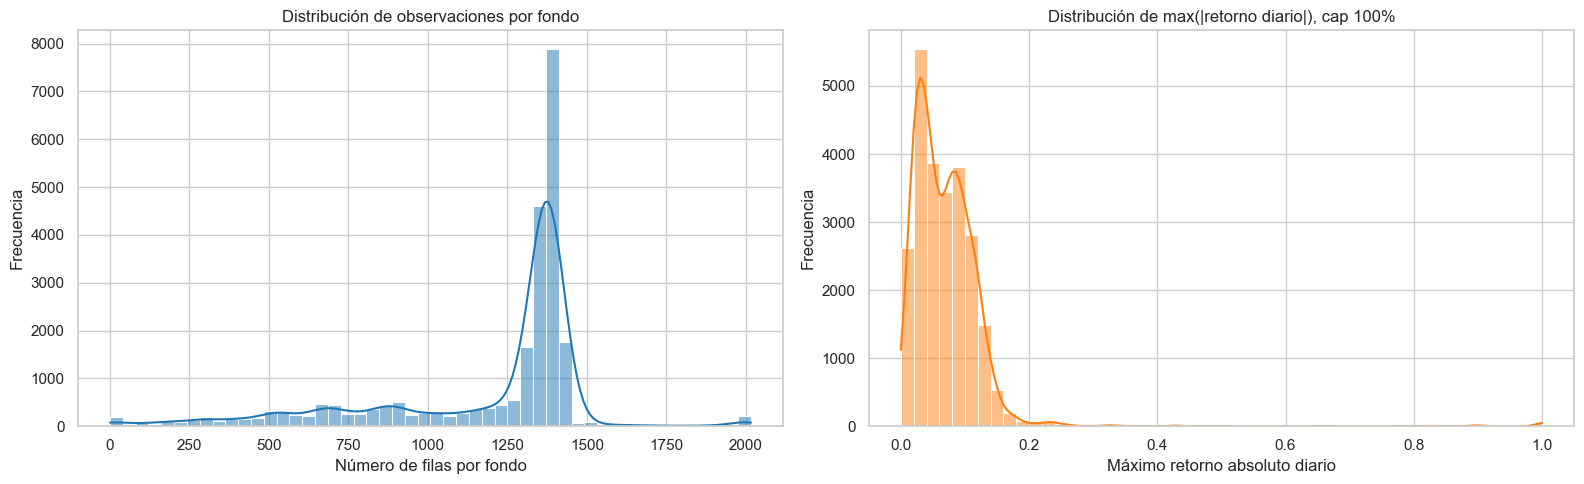

Cuantiles n_obs:
0.1     628.0
0.5    1352.0
0.9    1408.0
Name: n_obs, dtype: float64

Fondos con max_abs_ret > 50%: 102
Fondos con max_abs_ret > 20%: 311


In [5]:
# ==============================================================
# BLOQUE 5: Distribuciones relevantes para decisión de limpieza
# ============================================================== 
# Visualizamos el número de observaciones por fondo y la distribución
# de saltos máximos diarios en rentabilidad.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma del número de observaciones por fondo.
sns.histplot(meta_df["n_obs"], bins=50, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Distribución de observaciones por fondo")
axes[0].set_xlabel("Número de filas por fondo")
axes[0].set_ylabel("Frecuencia")

# Histograma de saltos extremos (capado para visualizar la zona de interés).
cap = meta_df["max_abs_ret"].clip(upper=1.0)
sns.histplot(cap, bins=50, kde=True, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Distribución de max(|retorno diario|), cap 100%")
axes[1].set_xlabel("Máximo retorno absoluto diario")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print("Cuantiles n_obs:")
print(meta_df["n_obs"].quantile([0.1, 0.5, 0.9]))

print("\nFondos con max_abs_ret > 50%:", int((meta_df["max_abs_ret"] > 0.5).sum()))
print("Fondos con max_abs_ret > 20%:", int((meta_df["max_abs_ret"] > 0.2).sum()))


La base tiene una masa principal de fondos con longitud temporal homogénea y relativamente alta, pero también contiene una fracción no despreciable de fondos con historia corta. Esto puede deberse a lanzamientos recientes, fondos desaparecidos, datos incompletos o problemas de cobertura.

Antes de modelizar o clusterizar fondos, no basta con cargar el dataset y calcular variables. Hay que entender si las series son comparables entre sí.

Este bloque hace una auditoría básica de calidad a nivel de fondo. Por un lado, vemos si cada activo tiene suficiente profundidad histórica. Por otro, detectamos si existen saltos diarios extremos que puedan contaminar métricas posteriores.

Los histogramas nos dan una visión global y los cuantiles/conteos nos permiten traducir esa intuición visual en criterios objetivos de limpieza.

## 3. Criterios de limpieza (justificados)

Usaremos filtros conservadores para quedarnos con series útiles para extracción de características:

1. `n_obs >= 252`: al menos un año bursátil aproximado de observaciones.
2. `max_abs_ret <= 0.50`: elimina series con saltos de escala muy agresivos (por ejemplo 100x).

Estos filtros son razonables porque:

- Evitan ruido por cambios de unidad/denominación NAV.
- Mantienen una cobertura muy amplia de fondos.
- Mejoran la estabilidad de métricas como volatilidad, drawdown y betas.


In [6]:
# ==============================================================
# BLOQUE 6: Aplicación de filtros de calidad
# ============================================================== 
# Construimos la lista de fondos elegibles para extracción de features.

eligible_ids = meta_df.loc[
    (meta_df["n_obs"] >= 252) &
    (meta_df["max_abs_ret"] <= 0.50),
    "allfunds_id"
].tolist()

print("Fondos elegibles tras filtros:", len(eligible_ids))
print("Fondos descartados:", len(meta_df) - len(eligible_ids))


Fondos elegibles tras filtros: 24144
Fondos descartados: 678


## 4. Carga y preparación de factores Fama-French (Asia ex Japan)

Para conectar los fondos con la tesis financiera, incorporamos factores diarios:

- `Mkt-RF`, `SMB`, `HML`, `RF` desde `ff_asia_pacific_3factors_daily.csv`.
- `WML` (momentum) desde `mom_asia_pacific_daily.csv`.

Importante: los factores vienen en **porcentaje diario**, por lo que se convierten a escala decimal.


Nota técnica: en estos nuevos ficheros la fecha viene como `YYYY-MM-DD`; el código se ha hecho robusto para aceptar también `YYYYMMDD` por compatibilidad.


In [7]:
# ==============================================================
# BLOQUE 7: Lectura y unión de factores
# ==============================================================
# Usamos los ficheros actualizados entregados por el profesor.
# Diferencia importante respecto a la versión anterior:
# - Ahora la columna Date suele venir en formato YYYY-MM-DD.
# - Aun así, hacemos el parseo robusto para admitir también YYYYMMDD.

ff3_path = DATASET_DIR / "ff_asia_pacific_3factors_daily.csv"
mom_path = DATASET_DIR / "mom_asia_pacific_daily.csv"

ff3 = pd.read_csv(ff3_path)
mom = pd.read_csv(mom_path)

# Función de parseo robusto de fechas.
def parse_mixed_date(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()

    # Si detectamos guiones, asumimos formato ISO (YYYY-MM-DD).
    has_dash = s.str.contains("-", regex=False).any()
    if has_dash:
        dt = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
    else:
        dt = pd.to_datetime(s, format="%Y%m%d", errors="coerce")

    # Fallback adicional por seguridad ante formatos mixtos.
    if dt.isna().mean() > 0.2:
        dt = pd.to_datetime(s, errors="coerce")

    return dt

ff3["Date"] = parse_mixed_date(ff3["Date"])
mom["Date"] = parse_mixed_date(mom["Date"])

# Nos quedamos con intersección de fechas para trabajar con factores completos.
factors = ff3.merge(mom, on="Date", how="inner").sort_values("Date").reset_index(drop=True)

# Convertimos de porcentaje a tanto por uno.
for col in ["Mkt-RF", "SMB", "HML", "RF", "WML"]:
    factors[col] = pd.to_numeric(factors[col], errors="coerce") / 100.0

print("Archivo FF3 usado:", ff3_path.name)
print("Archivo MOM usado:", mom_path.name)
print("Rango temporal factores:", factors["Date"].min(), "->", factors["Date"].max())
print("Dimensión de factores:", factors.shape)
print("Nulos por columna:")
print(factors[["Mkt-RF", "SMB", "HML", "RF", "WML"]].isna().sum())
display(factors.head())



Archivo FF3 usado: ff_asia_pacific_3factors_daily.csv
Archivo MOM usado: mom_asia_pacific_daily.csv
Rango temporal factores: 1990-11-01 00:00:00 -> 2026-01-30 00:00:00
Dimensión de factores: (9197, 6)
Nulos por columna:
Mkt-RF    0
SMB       0
HML       0
RF        0
WML       0
dtype: int64


,Date,Mkt-RF,SMB,HML,RF,WML
0,1990-11-01,-0.0138,0.0097,0.0007,0.0003,0.0072
1,1990-11-02,-0.0103,-0.0005,-0.0026,0.0003,0.0096
2,1990-11-05,0.0120,-0.0067,0.0026,0.0003,-0.0141
3,1990-11-06,0.0040,0.0001,-0.0030,0.0003,-0.0013
4,1990-11-07,-0.0022,-0.0051,-0.0043,0.0003,0.0001


En este bloque construimos la tabla maestra de factores.

Leemos por separado los factores FF3 y momentum, robustecemos el parseo de fechas porque los ficheros pueden venir en formatos distintos, y luego los unimos por intersección temporal. La lógica del inner merge es muy importante: preferimos quedarnos solo con las fechas en las que todos los factores están disponibles, para evitar huecos en la matriz explicativa.

Después convertimos los factores de porcentaje a tanto por uno, porque esa es la escala natural para trabajar en regresión y análisis cuantitativo.

El resultado final es una serie diaria larga, limpia y sin nulos, lista para alinearse con los retornos de los fondos.

## 5. Extracción de características por fondo

Para cada fondo elegible calcularemos:

- **Retorno anualizado** y **volatilidad anualizada**.
- **Sharpe** (exceso sobre RF) y **Sortino**.
- **Máximo drawdown**.
- **Asimetría** y **curtosis** de retornos.
- Betas frente a `Mkt-RF`, `SMB`, `HML`, `WML` mediante regresión lineal OLS.
- Indicadores de texto (`asia_name_flag`, `japan_name_flag`, `pacific_name_flag`) como señal auxiliar.


In [8]:
# ==============================================================
# BLOQUE 8: Funciones auxiliares de métricas cuantitativas
# ============================================================== 
# Definimos funciones pequeñas y reutilizables para mantener el código
# limpio, legible y fácil de transportar al segundo notebook.

def max_drawdown_from_returns(returns: pd.Series) -> float:
    """Calcula el máximo drawdown a partir de una serie de retornos diarios."""
    if returns is None or len(returns) == 0:
        return np.nan

    # Curva de patrimonio acumulada empezando en 1.
    equity_curve = (1.0 + returns).cumprod()

    # Máximo histórico acumulado.
    rolling_peak = equity_curve.cummax()

    # Drawdown en cada instante.
    drawdown = (equity_curve / rolling_peak) - 1.0

    return float(drawdown.min())


def fit_factor_betas(df_merged: pd.DataFrame):
    """Ajusta OLS sencillo: (r_fondo - RF) = alpha + betas * factores."""
    needed_cols = ["excess_ret", "Mkt-RF", "SMB", "HML", "WML"]
    if df_merged[needed_cols].dropna().shape[0] < 60:
        # Si hay muy pocos puntos, devolvemos NaN para no introducir ruido.
        return (np.nan, np.nan, np.nan, np.nan, np.nan)

    reg_df = df_merged[needed_cols].dropna().copy()

    y = reg_df["excess_ret"].values
    X = reg_df[["Mkt-RF", "SMB", "HML", "WML"]].values

    # Añadimos intercepto (alpha).
    X = np.column_stack([np.ones(len(X)), X])

    # Resolución por mínimos cuadrados ordinarios.
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)

    alpha = float(coef[0])
    beta_mkt = float(coef[1])
    beta_smb = float(coef[2])
    beta_hml = float(coef[3])
    beta_wml = float(coef[4])

    return (alpha, beta_mkt, beta_smb, beta_hml, beta_wml)


En este bloque definimos dos funciones auxiliares que convierten series temporales en métricas económicamente interpretables.

La primera calcula el máximo drawdown, es decir, la peor caída acumulada desde un pico histórico. Para ello reconstruye una curva de patrimonio a partir de los retornos, calcula el máximo acumulado y mide en cada punto cuánto se ha caído respecto a ese techo.

La segunda función estima las exposiciones factoriales del fondo mediante una regresión OLS del retorno en exceso sobre los factores de mercado, tamaño, value y momentum. Si no hay al menos 60 observaciones útiles, preferimos no estimar nada para no introducir coeficientes poco fiables.

In [9]:
# ==============================================================
# BLOQUE 9: Feature engineering — OPTIMIZADO
# ==============================================================

import time
from tqdm.auto import tqdm  # barra de progreso en Jupyter

# ----------------------------------------------------------------
# PASO 1: Preparacion global de factores en arrays numpy (una sola vez)
# ----------------------------------------------------------------
factor_cols = ["Mkt-RF", "SMB", "HML", "RF", "WML"]
factors_idx = (
    factors[["Date"] + factor_cols]
    .dropna(subset=["Date"])
    .drop_duplicates(subset=["Date"], keep="last")
    .set_index("Date")
    .sort_index()
)

factor_dates_int = factors_idx.index.values.astype("datetime64[ns]").astype("int64")
factor_matrix    = factors_idx[factor_cols].to_numpy(dtype=float)

factor_min_date = factors_idx.index.min()
factor_max_date = factors_idx.index.max()

# ----------------------------------------------------------------
# PASO 2: Pre-procesar navs_dict -> cache de arrays numpy
# ----------------------------------------------------------------
# UNA sola pasada pandas por fondo, fuera del loop de calculo.
# El loop de features trabaja solo con arrays int64/float64 nativos.

print("Pre-procesando navs_dict a arrays numpy...", flush=True)
t0 = time.time()

nav_cache = {}  # fund_id -> (dates_int64, nav_float64, name_str, isin_str)

for fund_id, df in navs_dict.items():
    try:
        dates_np = pd.to_datetime(df.index, errors="coerce").to_numpy("datetime64[ns]")
        nav_np   = pd.to_numeric(df["nav"], errors="coerce").to_numpy(dtype=float)
        name_val = str(df["name"].iloc[-1]).strip() if "name" in df.columns else ""
        isin_val = str(df["isin"].iloc[-1]).strip() if "isin" in df.columns else ""
        nav_cache[fund_id] = (dates_np.astype("int64"), nav_np, name_val, isin_val)
    except Exception:
        pass

print(f"Cache construido: {len(nav_cache)} fondos en {time.time()-t0:.1f}s", flush=True)

# ----------------------------------------------------------------
# PASO 3: Prefiltro de fondos elegibles
# ----------------------------------------------------------------
if "meta_df" in globals() and isinstance(meta_df, pd.DataFrame):
    eligible_ids_fast = meta_df.loc[
        (meta_df["n_obs"] >= 252) &
        (meta_df["max_abs_ret"] <= 0.50) &
        (meta_df["start_date"] <= factor_max_date) &
        (meta_df["end_date"]   >= factor_min_date),
        "allfunds_id"
    ].tolist()
else:
    eligible_ids_fast = list(eligible_ids)

eligible_ids_fast = [fid for fid in eligible_ids_fast if fid in nav_cache]
print(f"Fondos elegibles tras prefiltro: {len(eligible_ids_fast)}", flush=True)

sqrt_252 = np.sqrt(252.0)
INT64_NaT = np.iinfo(np.int64).min  # valor que pandas usa para NaT en int64

# ----------------------------------------------------------------
# PASO 4: OLS matricial (puro numpy, sin pandas)
# ----------------------------------------------------------------

def _ols_coefficients(X, y):
    finite_mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    if finite_mask.sum() < 60:
        return (np.nan, np.nan, np.nan, np.nan, np.nan)
    Xf = X[finite_mask]
    yf = y[finite_mask]
    Xd = np.column_stack([np.ones(len(Xf)), Xf])
    XtX = Xd.T @ Xd
    Xty = Xd.T @ yf
    try:
        coef = np.linalg.solve(XtX, Xty)
    except np.linalg.LinAlgError:
        coef, *_ = np.linalg.lstsq(Xd, yf, rcond=None)
    return tuple(map(float, coef))

# ----------------------------------------------------------------
# PASO 5: Loop principal — puro numpy, sin pandas en el hot path
# ----------------------------------------------------------------
# Sin joblib, sin procesos, sin hilos: un loop Python limpio sobre
# arrays numpy es suficientemente rapido porque:
# - Cero overhead de serializacion/spawn de procesos.
# - Cero llamadas pandas por iteracion.
# - numpy interno usa BLAS/MKL multi-hilo para operaciones matriciales.

feature_rows = []
t1 = time.time()

for fund_id in tqdm(eligible_ids_fast, desc="Calculando features"):
    cached = nav_cache.get(fund_id)
    if cached is None:
        continue

    dates_int_raw, nav_raw, name_last, isin_last = cached

    # Máscara de validez
    valid = (dates_int_raw != INT64_NaT) & np.isfinite(nav_raw)
    if valid.sum() < 252:
        continue

    dates_int = dates_int_raw[valid]
    nav       = nav_raw[valid]

    # Ordenación temporal
    order     = np.argsort(dates_int, kind="stable")
    dates_int = dates_int[order]
    nav       = nav[order]

    # Retornos diarios
    prev_nav = nav[:-1]
    curr_nav = nav[1:]
    good_den = prev_nav != 0.0
    if good_den.sum() < 252:
        continue

    ret = np.full(len(prev_nav), np.nan, dtype=float)
    ret[good_den] = (curr_nav[good_den] / prev_nav[good_den]) - 1.0
    ret_dates_int = dates_int[1:]

    finite_ret = np.isfinite(ret)
    if finite_ret.sum() < 252:
        continue

    ret           = ret[finite_ret]
    ret_dates_int = ret_dates_int[finite_ret]

    # Intersección con factores
    common_dates, idx_ret, idx_fac = np.intersect1d(
        ret_dates_int,
        factor_dates_int,
        assume_unique=True,
        return_indices=True,
    )
    if len(common_dates) < 120:
        continue

    r   = ret[idx_ret]
    fac = factor_matrix[idx_fac]

    rf     = fac[:, 3]
    excess = r - rf

    # Métricas anualizadas
    mean_r  = float(np.nanmean(r))
    std_r   = float(np.nanstd(r, ddof=1)) if len(r) > 1 else np.nan

    ann_return  = float((1.0 + mean_r) ** 252 - 1.0)
    ann_vol     = float(std_r * sqrt_252) if np.isfinite(std_r) else np.nan
    ann_excess  = float(np.nanmean(excess) * 252)

    neg          = r[r < 0]
    downside_std = float(np.std(neg, ddof=1) * sqrt_252) if len(neg) > 1 else np.nan

    sharpe  = ann_excess / ann_vol      if (np.isfinite(ann_vol)      and ann_vol > 0)      else np.nan
    sortino = ann_excess / downside_std if (np.isfinite(downside_std) and downside_std > 0) else np.nan

    # Máximo drawdown
    equity_curve = np.cumprod(1.0 + r)
    rolling_peak = np.maximum.accumulate(equity_curve)
    mdd          = float(np.min((equity_curve / rolling_peak) - 1.0))

    # Asimetría y curtosis
    if np.isfinite(std_r) and std_r > 0:
        z        = (r - mean_r) / std_r
        ret_skew = float(np.mean(z ** 3))
        ret_kurt = float(np.mean(z ** 4) - 3.0)
    else:
        ret_skew = ret_kurt = np.nan

    # Betas OLS
    alpha, beta_mkt, beta_smb, beta_hml, beta_wml = _ols_coefficients(fac[:, [0,1,2,4]], excess)

    # Flags de nombre
    fund_name_lc      = name_last.lower()
    asia_name_flag    = int("asia"    in fund_name_lc)
    japan_name_flag   = int("japan"   in fund_name_lc)
    pacific_name_flag = int("pacific" in fund_name_lc)

    # Fechas de inicio/fin
    matched_dates = ret_dates_int[idx_ret].astype("datetime64[ns]")
    start_date    = pd.Timestamp(matched_dates.min())
    end_date      = pd.Timestamp(matched_dates.max())

    feature_rows.append({
        "allfunds_id":       fund_id,
        "isin":              isin_last,
        "name_last":         name_last,
        "n_obs":             int(len(r)),
        "start_date":        start_date,
        "end_date":          end_date,
        "ann_return":        ann_return,
        "ann_vol":           ann_vol,
        "sharpe":            sharpe,
        "sortino":           sortino,
        "max_drawdown":      mdd,
        "ret_skew":          ret_skew,
        "ret_kurt":          ret_kurt,
        "alpha_daily":       alpha,
        "beta_mkt":          beta_mkt,
        "beta_smb":          beta_smb,
        "beta_hml":          beta_hml,
        "beta_wml":          beta_wml,
        "asia_name_flag":    asia_name_flag,
        "japan_name_flag":   japan_name_flag,
        "pacific_name_flag": pacific_name_flag,
    })

elapsed = time.time() - t1
print(f"\nLoop completado en {elapsed/60:.1f} min ({elapsed:.0f}s)")

features_df = pd.DataFrame(feature_rows)
print(f"Fondos candidatos tras prefiltro: {len(eligible_ids_fast)}")
print(f"Fondos con features calculadas:   {len(features_df)}")
display(features_df.head())


Pre-procesando navs_dict a arrays numpy...
Cache construido: 24822 fondos en 31.7s
Fondos elegibles tras prefiltro: 24144


Calculando features:   0%|          | 0/24144 [00:00<?, ?it/s]


Loop completado en 31.9 min (1913s)
Fondos candidatos tras prefiltro: 24144
Fondos con features calculadas:   24143


,allfunds_id,isin,name_last,n_obs,start_date,end_date,ann_return,ann_vol,sharpe,sortino,...,ret_skew,ret_kurt,alpha_daily,beta_mkt,beta_smb,beta_hml,beta_wml,asia_name_flag,japan_name_flag,pacific_name_flag
0,90,LU0171310443,"BGF WORLD TECHNOLOGY ""A2"" (EUR)",1386,2016-01-06,2021-07-16,0.331245,0.217922,1.268530,1.613216,...,-0.448630,3.786527,0.000855,0.780857,0.214853,-0.210214,0.169117,0,0,0
1,541,LU0248272758,"BGF INDIA ""A2""",1372,2016-01-06,2021-07-16,0.126756,0.216646,0.505554,0.575939,...,-1.490620,21.567331,0.000163,1.015285,0.444740,0.351305,0.132215,0,0,0
2,909,LU1408527916,"BGF EMERGING MARKETS ""A"" (GBPHDG) D",1298,2016-05-12,2021-07-16,-0.022353,0.078495,-0.421794,-0.436128,...,-1.626065,22.322279,-0.000201,0.318297,0.215135,0.032284,0.030707,0,0,0
3,915,LU1408528211,"BGF EMERGING MARKETS ""A"" (USD) D",1298,2016-05-12,2021-07-16,-0.041834,0.094809,-0.561485,-0.697634,...,-0.965635,6.803341,-0.000291,0.431815,0.327257,0.091182,0.007561,0,0,0
4,922,LU1408528302,"BGF EMERGING MARKETS ""A"" (GBPHDG) D A",1298,2016-05-12,2021-07-16,-0.058292,0.094963,-0.742987,-0.909773,...,-1.053296,7.154169,-0.000360,0.433554,0.333814,0.094721,0.011600,0,0,0


En este bloque pasamos de una colección de series NAV a una matriz de características por fondo.

Para hacerlo viable sobre más de 24.000 fondos, sustituimos gran parte del trabajo repetitivo de pandas por arrays NumPy cacheados, de modo que el bucle principal sea lo más ligero posible.

Después aplicamos filtros de elegibilidad, calculamos retornos diarios, alineamos cada fondo con la tabla de factores y extraemos métricas de rentabilidad, riesgo, drawdown, forma de la distribución y betas factoriales.

El resultado final es un DataFrame donde cada fondo queda representado por un vector compacto y económicamente interpretable, listo para tareas posteriores como clustering o segmentación.

In [10]:
# ==============================================================
# BLOQUE 10: Revisión final y exportación
# ============================================================== 
# Limpiamos posibles infinitos y revisamos nulos en features numéricas.

numeric_cols = [
    "ann_return", "ann_vol", "sharpe", "sortino", "max_drawdown",
    "ret_skew", "ret_kurt", "alpha_daily", "beta_mkt", "beta_smb", "beta_hml", "beta_wml"
]

features_df[numeric_cols] = features_df[numeric_cols].replace([np.inf, -np.inf], np.nan)

missing_report = features_df[numeric_cols].isna().mean().sort_values(ascending=False)
print("Porcentaje de nulos por feature numérica:")
print((missing_report * 100).round(2))

# Guardamos el dataset base.
out_path = DATASET_DIR / "features_fondos_part1.csv"
features_df.to_csv(out_path, index=False, encoding="utf-8")

print("\nArchivo exportado:", out_path)
print("Filas x columnas:", features_df.shape)


Porcentaje de nulos por feature numérica:
sortino         0.13
sharpe          0.07
ret_kurt        0.07
ret_skew        0.07
ann_return      0.00
ann_vol         0.00
max_drawdown    0.00
alpha_daily     0.00
beta_mkt        0.00
beta_smb        0.00
beta_hml        0.00
beta_wml        0.00
dtype: float64

Archivo exportado: C:\Users\rvill\Desktop\MIAX\3 Inteligencia Artificial\26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó\Taller ML\dataset\features_fondos_part1.csv
Filas x columnas: (24143, 21)


Una vez construida la matriz de features, hacemos una revisión final de calidad.

En particular, sustituimos posibles infinitos por valores nulos porque los infinitos suelen provenir de divisiones degeneradas y no son utilizables en modelado.

Después cuantificamos el porcentaje de missing por variable numérica y comprobamos que es residual, lo que valida la robustez del pipeline anterior.

Finalmente, exportamos el dataset resultante a CSV para desacoplar la fase de construcción de variables de la fase de análisis o clustering posterior.

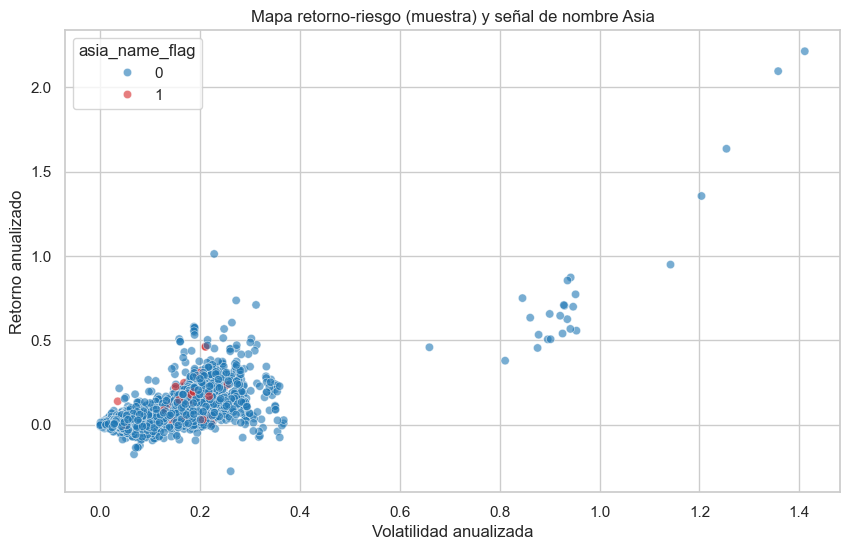

In [11]:
# ==============================================================
# BLOQUE 11: Visualización rápida para interpretación financiera
# ============================================================== 
# Esta visualización ayuda a entender perfiles retorno-riesgo.

plot_df = features_df.dropna(subset=["ann_return", "ann_vol"]).copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df.sample(min(5000, len(plot_df)), random_state=42),
    x="ann_vol",
    y="ann_return",
    hue="asia_name_flag",
    alpha=0.6,
    palette={0: "#1f77b4", 1: "#d62728"}
)
plt.title("Mapa retorno-riesgo (muestra) y señal de nombre Asia")
plt.xlabel("Volatilidad anualizada")
plt.ylabel("Retorno anualizado")
plt.legend(title="asia_name_flag")
plt.show()


En esta visualización representamos cada fondo en un plano retorno-riesgo, usando en el eje X la volatilidad anualizada y en el eje Y la rentabilidad anualizada. Esto nos permite ver la estructura general del universo de fondos y detectar tanto la masa principal como los casos extremos.

Además, coloreamos los puntos según una señal muy simple derivada del nombre del fondo, asia_name_flag, para explorar si los fondos cuyo nombre contiene “Asia” parecen concentrarse en alguna región específica del plano.

A simple vista, no se observa una separación tajante: estos fondos aparecen mezclados con el resto, lo que sugiere que esa señal textual por sí sola no segmenta claramente el perfil retorno-riesgo del universo.

## 6. Matriz de clustering + benchmark Asia + regla de selección

En este bloque:

1. Construimos una **matriz `X_clust`** con variables finales, tratamiento de nulos y estandarización.
2. Construimos un **benchmark proxy Asia ex Japan** con la identidad:
   $$R_m = (Mkt-RF) + RF$$
3. Definimos un **criterio explícito de selección** de fondos alineados con la tesis Asia.


% nulos antes de imputar (variables de clustering):
sortino         0.13
ret_skew        0.07
sharpe          0.07
ret_kurt        0.07
ann_return      0.00
ann_vol         0.00
max_drawdown    0.00
beta_mkt        0.00
beta_smb        0.00
beta_hml        0.00
beta_wml        0.00
dtype: float64

Nulos restantes tras imputación: 0

Matriz X_clust creada correctamente
Shape X_clust (filas x columnas): (24143, 11)
Archivo exportado: C:\Users\rvill\Desktop\MIAX\3 Inteligencia Artificial\26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó\Taller ML\dataset\X_clust_part1.csv


,allfunds_id,ann_return,ann_vol,sharpe,sortino,max_drawdown,ret_skew,ret_kurt,beta_mkt,beta_smb,beta_hml,beta_wml
0,90,2.572859,1.058647,0.117819,0.067748,-0.379156,0.493136,-0.474868,1.064592,0.457195,-1.255346,1.107938
1,541,0.478884,1.044508,0.044310,0.026597,-1.657174,-0.031848,-0.088638,1.786670,1.548688,2.374542,0.787552
2,909,-1.048008,-0.486953,-0.045035,-0.013554,-0.697088,-0.100089,-0.072240,-0.360170,0.458536,0.312265,-0.093749
3,915,-1.247495,-0.306106,-0.058494,-0.023929,-0.935344,0.232654,-0.409338,-0.010515,0.990884,0.693004,-0.294705
4,922,-1.416034,-0.304390,-0.075981,-0.032345,-1.197577,0.188489,-0.401717,-0.005159,1.022017,0.715881,-0.259638


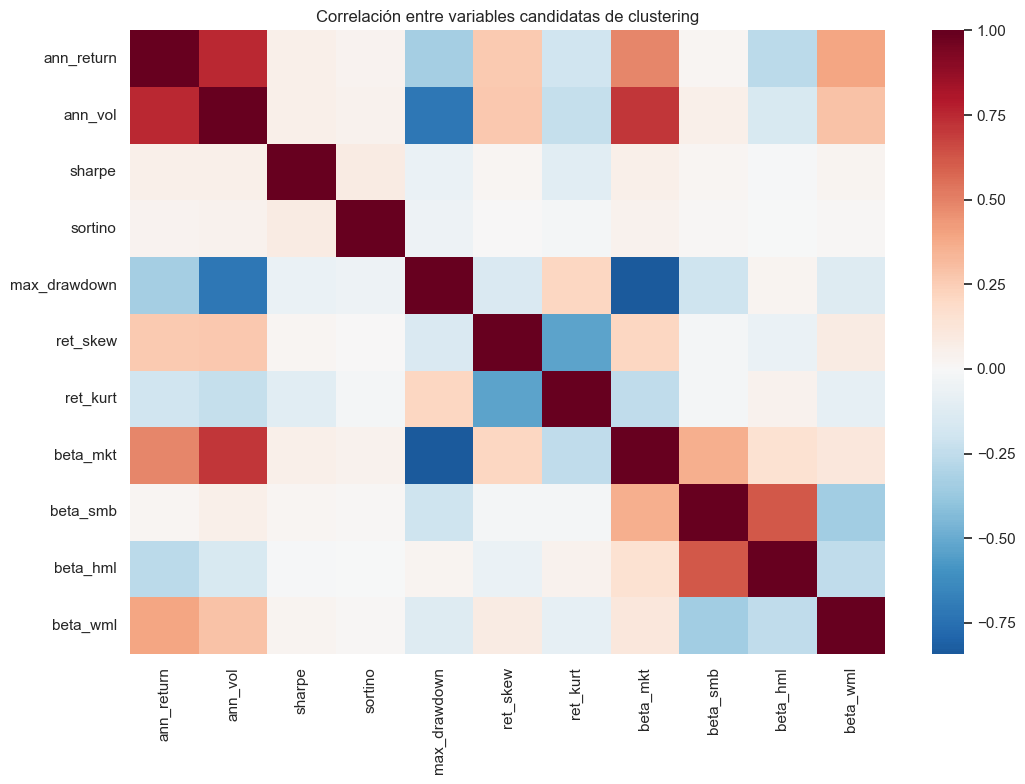

In [12]:
# ==============================================================
# BLOQUE 12: Matriz final para clustering (X_clust)
# ==============================================================
# Este bloque convierte el DataFrame de features en una matriz lista
# para algoritmos de clustering.
#
# Decisiones metodológicas:
# - Selección explícita de variables de perfil financiero.
# - Imputación robusta de nulos por mediana (evita sesgos por outliers).
# - Estandarización con media 0 y varianza 1 (imprescindible para distancias).

from sklearn.preprocessing import StandardScaler

# 1) Variables finales elegidas para clustering.
# Incluimos rentabilidad/riesgo, forma de la distribución y exposiciones factoriales.
clustering_features = [
    "ann_return",
    "ann_vol",
    "sharpe",
    "sortino",
    "max_drawdown",
    "ret_skew",
    "ret_kurt",
    "beta_mkt",
    "beta_smb",
    "beta_hml",
    "beta_wml",
]

# 2) Construimos una tabla de trabajo solo con ID + variables seleccionadas.
clust_df = features_df[["allfunds_id"] + clustering_features].copy()

# 3) Sustituimos infinitos por nulos para evitar problemas numéricos posteriores.
clust_df[clustering_features] = clust_df[clustering_features].replace([np.inf, -np.inf], np.nan)

# 4) Auditoría de nulos previa a imputación.
missing_before = clust_df[clustering_features].isna().mean().sort_values(ascending=False)
print("% nulos antes de imputar (variables de clustering):")
print((missing_before * 100).round(2))

# 5) Imputación por mediana columna a columna.
# Esta opción es robusta y mantiene la escala típica de cada variable.
for col in clustering_features:
    med = clust_df[col].median(skipna=True)
    clust_df[col] = clust_df[col].fillna(med)

# 6) Confirmamos que no quedan nulos.
missing_after = clust_df[clustering_features].isna().sum().sum()
print("\nNulos restantes tras imputación:", int(missing_after))

# 7) Estandarización para que todas las variables contribuyan en igualdad de condiciones.
# StandardScaler resta la media y divide por la desviación típica de cada variable.
scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(clust_df[clustering_features])

# 8) Guardamos la matriz en DataFrame para trazabilidad (ID + variables escaladas).
X_clust_df = pd.DataFrame(X_clust, columns=clustering_features)
X_clust_df.insert(0, "allfunds_id", clust_df["allfunds_id"].values)

# 9) Exportamos la matriz final.
xclust_path = DATASET_DIR / "X_clust_part1.csv"
X_clust_df.to_csv(xclust_path, index=False, encoding="utf-8")

print("\nMatriz X_clust creada correctamente")
print("Shape X_clust (filas x columnas):", X_clust.shape)
print("Archivo exportado:", xclust_path)
display(X_clust_df.head())

# 10) Gráfico de correlación en crudo (sin escalar) para entender redundancias.
plt.figure(figsize=(11, 8))
corr = clust_df[clustering_features].corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False)
plt.title("Correlación entre variables candidatas de clustering")
plt.tight_layout()
plt.show()


En este bloque construimos la matriz final que alimentará el clustering.

Primero seleccionamos un subconjunto de variables que resume el perfil financiero de cada fondo:

+ rentabilidad
+ riesgo
+ ratios ajustados
+ drawdown
+ forma de la distribución
+ exposiciones factoriales.

Después sustituimos posibles infinitos por nulos y realizamos una imputación por mediana, que es robusta frente a outliers.

Una vez garantizada la completitud, estandarizamos todas las variables con StandardScaler, porque en clustering basado en distancias es fundamental que todas contribuyan en una escala comparable. 

Finalmente, exportamos la matriz resultante y visualizamos la correlación entre variables para detectar redundancias y entender mejor la geometría del espacio en el que vamos a agrupar los fondos.

Rango del benchmark proxy: 1990-11-01 00:00:00 -> 2026-01-30 00:00:00
Retorno anualizado proxy: 10.37%
Volatilidad anualizada proxy: 16.34%


,Date,Mkt-RF,RF,rm_proxy,asia_proxy_index
0,1990-11-01,-0.0138,0.0003,-0.0135,98.650000
1,1990-11-02,-0.0103,0.0003,-0.0100,97.663500
2,1990-11-05,0.0120,0.0003,0.0123,98.864761
3,1990-11-06,0.0040,0.0003,0.0043,99.289880
4,1990-11-07,-0.0022,0.0003,-0.0019,99.101229


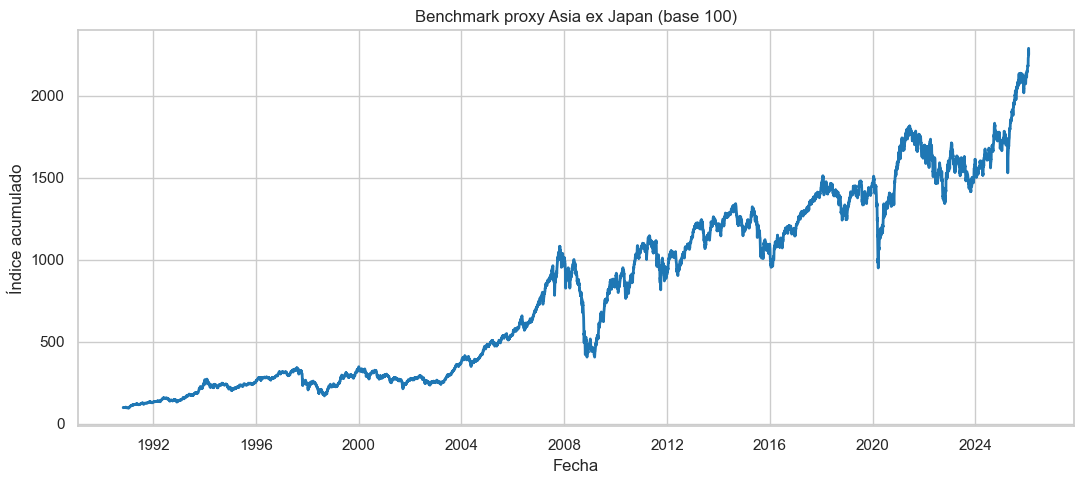

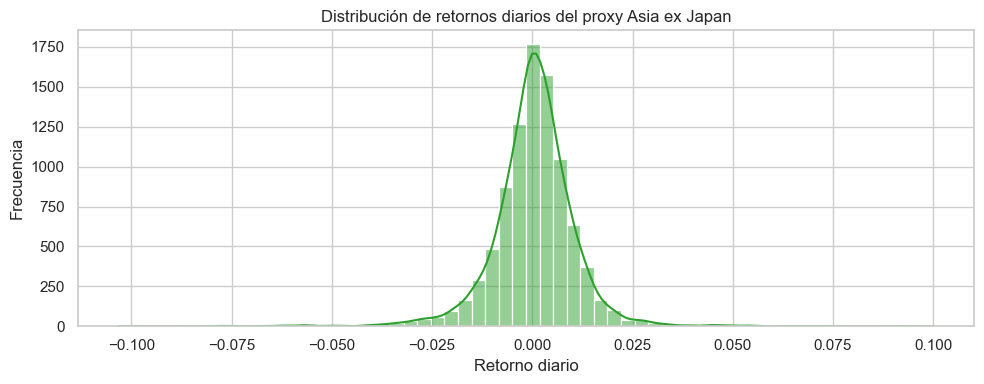

In [13]:
# ==============================================================
# BLOQUE 13: Benchmark proxy Asia ex Japan (R_m = Mkt-RF + RF)
# ==============================================================
# Construimos un proxy del mercado asiático (ex Japan) a partir de factores.
#
# Recordatorio:
# - Mkt-RF representa el exceso de retorno del mercado sobre RF.
# - Sumando RF recuperamos el retorno total del mercado: R_m.

benchmark_df = factors[["Date", "Mkt-RF", "RF"]].dropna().copy()
benchmark_df = benchmark_df.sort_values("Date").reset_index(drop=True)

# Retorno diario del proxy de mercado asiático (ex Japan).
benchmark_df["rm_proxy"] = benchmark_df["Mkt-RF"] + benchmark_df["RF"]

# Índice acumulado base 100 para interpretación visual intuitiva.
benchmark_df["asia_proxy_index"] = 100.0 * (1.0 + benchmark_df["rm_proxy"]).cumprod()

# Métricas descriptivas del benchmark proxy.
proxy_ann_return = (1.0 + benchmark_df["rm_proxy"].mean()) ** 252 - 1.0
proxy_ann_vol = benchmark_df["rm_proxy"].std(ddof=1) * np.sqrt(252.0)

print("Rango del benchmark proxy:", benchmark_df["Date"].min(), "->", benchmark_df["Date"].max())
print(f"Retorno anualizado proxy: {proxy_ann_return:.2%}")
print(f"Volatilidad anualizada proxy: {proxy_ann_vol:.2%}")
display(benchmark_df.head())

# Gráfico principal: evolución del índice proxy acumulado.
plt.figure(figsize=(11, 5))
plt.plot(benchmark_df["Date"], benchmark_df["asia_proxy_index"], color="#1f77b4", lw=2)
plt.title("Benchmark proxy Asia ex Japan (base 100)")
plt.xlabel("Fecha")
plt.ylabel("Índice acumulado")
plt.tight_layout()
plt.show()

# Gráfico complementario: distribución de retornos diarios del proxy.
plt.figure(figsize=(10, 4))
sns.histplot(benchmark_df["rm_proxy"], bins=60, kde=True, color="#2ca02c")
plt.title("Distribución de retornos diarios del proxy Asia ex Japan")
plt.xlabel("Retorno diario")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


En este bloque construimos un benchmark proxy del mercado Asia ex Japan a partir de los factores.

Como Mkt-RF representa el exceso de retorno del mercado sobre el activo libre de riesgo, al sumarle RF recuperamos una aproximación al retorno total del mercado.

A partir de esa serie diaria construimos un índice acumulado base 100 para visualizar la trayectoria histórica y calculamos sus métricas básicas de retorno y volatilidad.

El resultado muestra un mercado con una rentabilidad anualizada del 10,37% y una volatilidad del 16,34%, es decir, una prima de rentabilidad atractiva pero acompañada de episodios de caída severa.

El histograma de retornos diarios refuerza esta idea: la mayoría de días presentan movimientos pequeños, pero existen colas que reflejan shocks de mercado y comportamiento no perfectamente normal.

Umbral beta_mkt (P70): 0.6405
Umbral score tesis (P75): 0.6296
Fondos totales analizados: 24143
Fondos alineados con tesis Asia: 5027


,allfunds_id,isin,name_last,beta_mkt,sharpe,max_drawdown,asia_name_flag,japan_name_flag,asia_thesis_score,asia_aligned_flag
604,166659,LU2087589771,"BGF EMERGING MARKETS ""D2"" (EURHDG) A",1.050644,1.980115,-0.086824,0,0,0.968125,1
11753,293551,IE00BYSXR079,"MERIAN CHINA EQUITY ""A"" (EUR)",0.975125,1.224783,-0.095511,0,0,0.942607,1
12385,145810,LU1987882872,"DWS INVEST BRAZILIAN ""FC"" (EUR)",1.093332,1.469194,-0.178073,0,0,0.938875,1
20874,103181,LU1937674437,"EASTSPRING INV GLOBAL ""RE"" (EUR)",0.906196,2.052697,-0.074866,0,0,0.933150,1
16938,66862,LU0357529600,"LO FUNDS EME RES EQUITY EH ""R"" (USD)",1.001930,0.957657,-0.111709,0,0,0.928793,1
13221,153400,LU1983261865,"JANUS HENDERSON GLOBA ""H2"" (USD)",0.864489,2.553246,-0.075783,0,0,0.917340,1
22710,157661,IE00BGDW0265,NEW CAPITAL ASIA FUTU (GBPHDG),0.903583,3.061056,-0.134505,1,0,0.911560,1
17394,245901,LU2107592128,"LO FUNDS CLIMATE TRAN ""P"" (EURHDG) A",0.845465,1.721957,-0.068813,0,0,0.908135,1
603,166657,LU2087589425,"BGF EMERGING MARKETS ""D2"" (EUR) A",0.847161,1.792253,-0.076348,0,0,0.907062,1
22380,8367,IE00BYQG5606,"BAILLIE GIFFORD WORLD ""B"" (USD) A",1.083712,1.368658,-0.291775,0,0,0.901040,1



Archivo exportado con selección tesis Asia: C:\Users\rvill\Desktop\MIAX\3 Inteligencia Artificial\26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó\Taller ML\dataset\fondos_alineados_tesis_asia_part1.csv


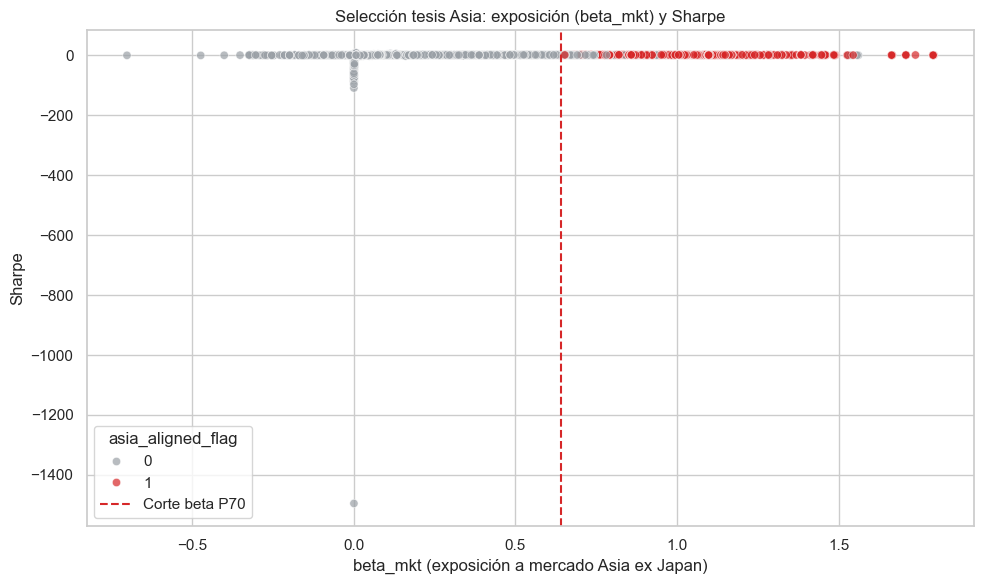

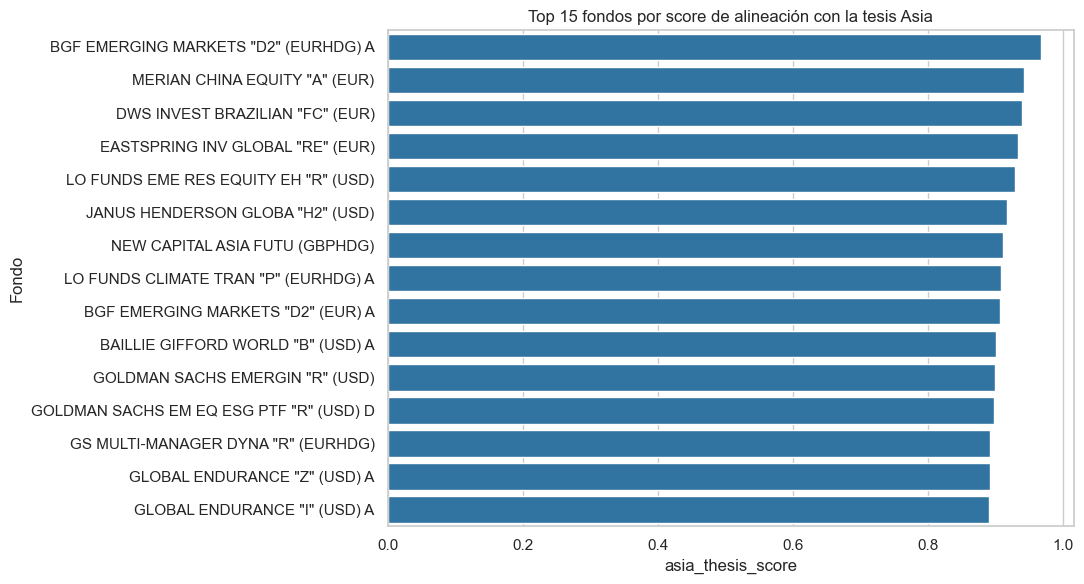

In [20]:
# ==============================================================
# BLOQUE 14: Criterio explícito de selección (tesis Asia)
# ==============================================================
# Objetivo: pasar de "medir exposición" a "seleccionar fondos".
# Definimos una regla transparente basada en:
# - Exposición al mercado Asia ex Japan (beta_mkt).
# - Calidad de rentabilidad ajustada al riesgo (Sharpe).
# - Control de pérdidas extremas (max_drawdown).
# - Señal semántica del nombre (asia_name_flag / japan_name_flag).

selection_df = features_df.copy()

# Nos quedamos con columnas necesarias y limpiamos infinitos.
sel_cols = ["beta_mkt", "sharpe", "max_drawdown", "asia_name_flag", "japan_name_flag"]
selection_df[sel_cols] = selection_df[sel_cols].replace([np.inf, -np.inf], np.nan)

# Imputación mínima para poder puntuar todos los fondos.
selection_df["beta_mkt"] = selection_df["beta_mkt"].fillna(selection_df["beta_mkt"].median())
selection_df["sharpe"] = selection_df["sharpe"].fillna(selection_df["sharpe"].median())
selection_df["max_drawdown"] = selection_df["max_drawdown"].fillna(selection_df["max_drawdown"].median())

# Normalización robusta por ranking percentil (evita sensibilidad a outliers).
selection_df["beta_rank"] = selection_df["beta_mkt"].rank(pct=True)
selection_df["sharpe_rank"] = selection_df["sharpe"].rank(pct=True)

# max_drawdown: cuanto menos negativo, mejor.
selection_df["drawdown_quality"] = selection_df["max_drawdown"].rank(pct=True)

# Score compuesto con pesos explícitos y trazables.
# Mayor peso en beta_mkt porque la tesis prioriza exposición a Asia.
selection_df["asia_thesis_score"] = (
    0.60 * selection_df["beta_rank"]
    + 0.25 * selection_df["sharpe_rank"]
    + 0.15 * selection_df["drawdown_quality"]
    + 0.00 * selection_df["asia_name_flag"]
    - 0.05 * selection_df["japan_name_flag"]
)

# Regla explícita de alineación con la tesis:
# 1) beta_mkt en percentil >= 70 (exposición alta al mercado Asia ex Japan).
# 2) score total en percentil >= 75 (combinación robusta de exposición + calidad).
beta_cut = selection_df["beta_mkt"].quantile(0.70)
score_cut = selection_df["asia_thesis_score"].quantile(0.75)

selection_df["asia_aligned_flag"] = (
    (selection_df["beta_mkt"] >= beta_cut)
    & (selection_df["asia_thesis_score"] >= score_cut)
).astype(int)

# Ranking final de candidatos.
selected_funds = selection_df.loc[selection_df["asia_aligned_flag"] == 1].copy()
selected_funds = selected_funds.sort_values("asia_thesis_score", ascending=False)

print("Umbral beta_mkt (P70):", round(beta_cut, 4))
print("Umbral score tesis (P75):", round(score_cut, 4))
print("Fondos totales analizados:", len(selection_df))
print("Fondos alineados con tesis Asia:", len(selected_funds))

display(selected_funds[[
    "allfunds_id", "isin", "name_last", "beta_mkt", "sharpe",
    "max_drawdown", "asia_name_flag", "japan_name_flag",
    "asia_thesis_score", "asia_aligned_flag"
]].head(10))

# Exportamos el ranking de selección para trazabilidad y uso directo.
selection_out_path = DATASET_DIR / "fondos_alineados_tesis_asia_part1.csv"
selected_funds.to_csv(selection_out_path, index=False, encoding="utf-8")
print("\nArchivo exportado con selección tesis Asia:", selection_out_path)

# Visualización 1: mapa beta_mkt vs Sharpe con fondos seleccionados resaltados.
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=selection_df,
    x="beta_mkt",
    y="sharpe",
    hue="asia_aligned_flag",
    palette={0: "#9aa0a6", 1: "#d62728"},
    alpha=0.70
)
plt.axvline(beta_cut, color="#d62728", linestyle="--", label="Corte beta P70")
plt.title("Selección tesis Asia: exposición (beta_mkt) y Sharpe")
plt.xlabel("beta_mkt (exposición a mercado Asia ex Japan)")
plt.ylabel("Sharpe")
plt.legend(title="asia_aligned_flag")
plt.tight_layout()
plt.show()

# Visualización 2: top 15 por score compuesto de la tesis.
top15 = selection_df.sort_values("asia_thesis_score", ascending=False).head(15).copy()

plt.figure(figsize=(11, 6))
sns.barplot(data=top15, y="name_last", x="asia_thesis_score", color="#1f77b4")
plt.title("Top 15 fondos por score de alineación con la tesis Asia")
plt.xlabel("asia_thesis_score")
plt.ylabel("Fondo")
plt.tight_layout()
plt.show()


En el gráfico "Selección tesis Asia: exposición (beta_mkt) y Sharpe aparecen algunos outliers numéricos severos en Sharpe que no son infinitos pero sí poco interpretables económicamente. No rompen el criterio porque usamos ranking percentil, pero son una señal de que este ratio debería quizá winsorizarse o caparse en una revisión posterior.

En este bloque dejamos de limitarnos a medir fondos y pasamos a seleccionar candidatos alineados con una tesis Asia ex Japan.

Para ello construimos un score compuesto que combina cuatro dimensiones:

+ exposición al mercado regional a través de beta_mkt
+ calidad retorno-riesgo mediante Sharpe
+ control de pérdidas extremas con max_drawdown
+ y una señal semántica basada en el nombre del fondo.

Para hacer las variables comparables y robustas frente a outliers, usamos rankings percentiles en lugar de valores crudos. Después imponemos una doble condición: estar al menos en el percentil 70 de beta_mkt y en el percentil 75 del score total. El resultado es un subconjunto de 4.677 fondos que representan aproximadamente el 19% del universo y que, según esta regla, están mejor alineados con la tesis Asia. Las visualizaciones permiten comprobar que la selección se concentra en fondos con mayor exposición de mercado y, además, revelan dos posibles mejoras del enfoque: la existencia de outliers severos en Sharpe y la repetición de múltiples share classes del mismo producto en el top del ranking.

Después de realizar varias pruebas se ha eliminado finalmente el parámetro de la señal semántica del nombre para evitar que un fondo entre en la selección simplemente por llamarse “Asia”. El criterio pasa a ser predominantemente financiero: prima la exposición estadística al mercado Asia ex Japan, seguida por la calidad retorno-riesgo y por el control de drawdown. Esto hace la selección más objetiva, aunque también permite que aparezcan fondos globales o emergentes cuyo comportamiento histórico haya estado muy alineado con Asia, aun sin tener un mandato geográfico explícito sobre la región.

Así, un fondo puede salir arriba porque:

- tiene sesgo emergente,
- o sesgo growth global,
- o una estructura de riesgo que históricamente ha covariado mucho con Asia ex Japan,

aunque su nombre no sea asiático.

In [15]:
# ==============================================================
# BLOQUE 15: Persistencia del escalador y metadatos de estandarización
# ==============================================================
# Guardamos el objeto StandardScaler ajustado en la Parte 1 para reutilizarlo
# en la Parte 2 sin reescalar X_clust por error.

import json

scaler_path = DATASET_DIR / "scaler_x_clust_part1.pkl"
with open(scaler_path, "wb") as f:
    pickle.dump(scaler_clust, f)

xclust_meta = {
    "x_clust_file": "X_clust_part1.csv",
    "is_standardized": True,
    "standardization_method": "StandardScaler",
    "scaler_file": "scaler_x_clust_part1.pkl",
    "do_not_rescale_in_part2": True,
}

meta_path = DATASET_DIR / "X_clust_part1_metadata.json"
meta_path.write_text(json.dumps(xclust_meta, ensure_ascii=False, indent=2), encoding="utf-8")

print("Scaler guardado en:", scaler_path)
print("Metadatos guardados en:", meta_path)


Scaler guardado en: C:\Users\rvill\Desktop\MIAX\3 Inteligencia Artificial\26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó\Taller ML\dataset\scaler_x_clust_part1.pkl
Metadatos guardados en: C:\Users\rvill\Desktop\MIAX\3 Inteligencia Artificial\26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó\Taller ML\dataset\X_clust_part1_metadata.json


En este bloque no generamos nuevas variables, pero sí aseguramos la reproducibilidad del pipeline. Guardamos el objeto StandardScaler ya ajustado en la Parte 1 para poder reutilizar exactamente la misma transformación en la Parte 2 o sobre nuevos datos. Además, creamos un archivo de metadatos que documenta que X_clust_part1.csv ya está estandarizado y que no debe volver a escalarse. Esto evita uno de los errores más habituales en pipelines de machine learning: aplicar transformaciones inconsistentes entre etapas del proyecto.

## 7. Conclusiones de la Parte 1

1. Se construyó un pipeline reproducible para transformar series NAV en un dataset de características por fondo, pasando de datos temporales heterogéneos a una base estructurada y comparable.

2. Se aplicaron filtros de robustez y controles de calidad para reducir el efecto de series problemáticas, valores extremos y datos no finitos, mejorando la estabilidad de las métricas calculadas.

3. Se integraron factores Asia ex Japan para estimar betas y exposiciones con significado económico, destacando beta_mkt como variable clave para medir alineación con la tesis.

4. Se dejó preparada la matriz X_clust, ya imputada y estandarizada, para su uso directo en técnicas de clustering en la Parte 2, garantizando además reproducibilidad mediante la persistencia del escalador.

5. Se construyó un benchmark proxy Asia ex Japan a partir de 
Rm=(Mkt−RF)+RF, aportando una referencia económica útil para contextualizar el comportamiento de los fondos.

6. Se definió una regla explícita y trazable de selección de fondos alineados con la tesis Asia, combinando exposición al mercado, calidad retorno-riesgo y control de drawdown en un criterio cuantitativo interpretable.